In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pickle
import pandas as pd
import torch
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc

In [2]:
y_true_F = torch.load("y_true_F")
y_pred_F = torch.load("y_pred_F")
y_prob_F = torch.load("y_prob_F")

y_true_S = torch.load("y_true_S")
y_pred_S = torch.load("y_pred_S")
y_prob_S = torch.load("y_prob_S")

y_true_T = torch.load("y_true_T")
y_pred_T = torch.load("y_pred_T")
y_prob_T = torch.load("y_prob_T")

cm_F = confusion_matrix(y_true_F, y_pred_F)
cm_S = confusion_matrix(y_true_S, y_pred_S)
cm_T = confusion_matrix(y_true_T, y_pred_T)

C:\Users\a3ebadi\AppData\Local\Temp\21\ipykernel_2360\413338513.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  y_true_F = torch.load("y_true_F")
C:\Users\a3ebadi\AppDat

In [ ]:
# plt.figure(figsize=(6, 4))
# ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

# # Add labels, title, and axis ticks
# ax.set_xlabel('Predicted Labels')
# ax.set_ylabel('True Labels')
# ax.set_title('Confusion Matrix (Full)')

# # Add custom class labels (optional, if binary classification)
# ax.xaxis.set_ticklabels(['Class 0', 'Class 1'])
# ax.yaxis.set_ticklabels(['Class 0', 'Class 1'])

# plt.show()

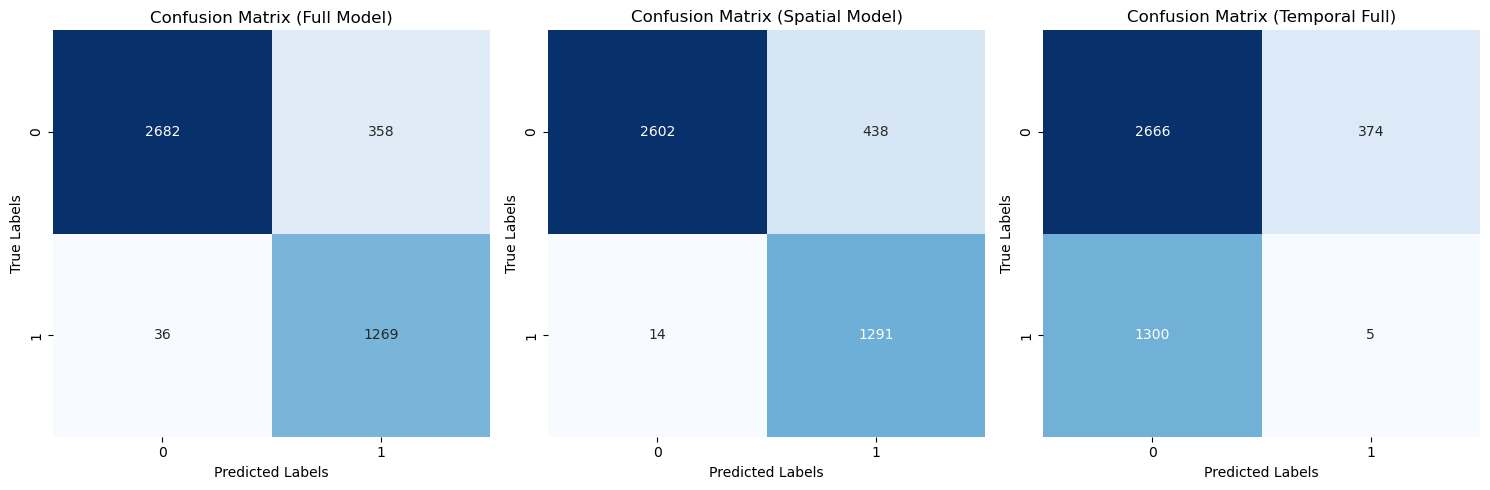

In [5]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# Plot data on each subplot
sns.heatmap(cm_F, annot=True, fmt='d', cmap='Blues', cbar=False, ax= ax1)
ax1.set_xlabel('Predicted Labels')
ax1.set_ylabel('True Labels')
ax1.set_title('Confusion Matrix (Full Model)')

sns.heatmap(cm_S, annot=True, fmt='d', cmap='Blues', cbar=False, ax = ax2)
ax2.set_xlabel('Predicted Labels')
ax2.set_ylabel('True Labels')
ax2.set_title('Confusion Matrix (Spatial Model)')

sns.heatmap(cm_T, annot=True, fmt='d', cmap='Blues', cbar=False, ax = ax3)
ax3.set_xlabel('Predicted Labels')
ax3.set_ylabel('True Labels')
ax3.set_title('Confusion Matrix (Temporal Full)')

# Adjust layout
plt.tight_layout()
plt.show()

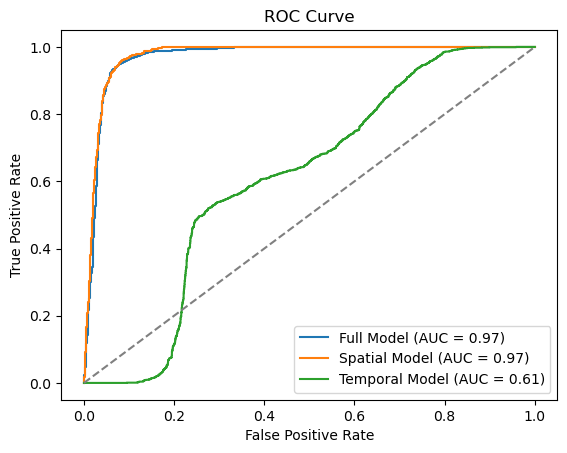

In [4]:
fpr_F, tpr_F, thresholds_F = roc_curve(y_true_F, y_prob_F)
roc_auc_F = auc(fpr_F, tpr_F)

fpr_S, tpr_S, thresholds_S = roc_curve(y_true_S, y_prob_S)
roc_auc_S = auc(fpr_S, tpr_S)

fpr_T, tpr_T, thresholds_T = roc_curve(y_true_T, y_prob_T)
roc_auc_T = auc(fpr_T, tpr_T)


plt.figure()
plt.plot(fpr_F, tpr_F, label=f'Full Model (AUC = {roc_auc_F:.2f})')
plt.plot(fpr_S, tpr_S, label=f'Spatial Model (AUC = {roc_auc_S:.2f})')
plt.plot(fpr_T, tpr_T, label=f'Temporal Model (AUC = {roc_auc_T:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()